# Imports

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from MC2PCA import MC2PCA
from metrics import ClusteringMetrics
from dataset_manager import DatasetManager

import numpy as np
import matplotlib.pyplot as plt


np.random.seed(0)


# Loading data

In [2]:
ds = DatasetManager("spoken_arabic_digits")
X_train, y_train = ds.X, ds.y

# Training of the model 

In [4]:
y_true_int = np.array(y_train).astype(int)

metrics = ClusteringMetrics()

for p in [1,2,3,4,5]:
    model = MC2PCA(p=p, tol=1e-7, max_iter=100)
    model.fit(X_train, K=10)

    metrics.add_run(
        y_true=y_true_int,
        y_pred=model.assignments,
        p=p,
        X=X_train
    )


# Evaluation

p=1 | ARI=0.163 | NMI=0.285 | Precision=0.338 | Recall=0.436
p=2 | ARI=0.172 | NMI=0.316 | Precision=0.380 | Recall=0.389
p=3 | ARI=0.190 | NMI=0.337 | Precision=0.414 | Recall=0.397
p=4 | ARI=0.183 | NMI=0.323 | Precision=0.384 | Recall=0.390
p=5 | ARI=0.144 | NMI=0.260 | Precision=0.346 | Recall=0.346


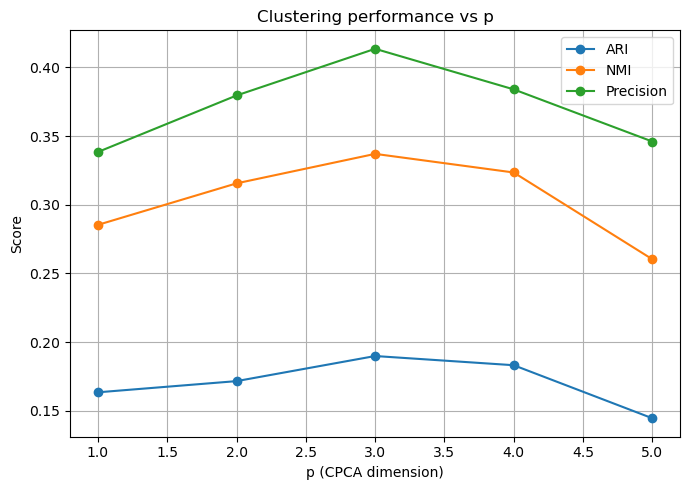

/Users/ilan/anaconda3/envs/kaggle/lib/python3.9/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/ilan/anaconda3/envs/kaggle/lib/python3.9/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


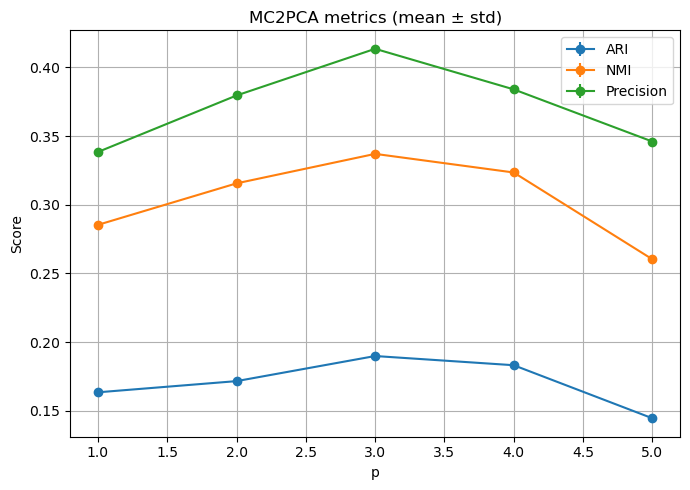

In [5]:
metrics.summary()
metrics.plot_metrics_vs_p()
metrics.plot_metrics_mean_std()

# Variation of the number of clusters

In [6]:
Ks = [8, 9, 10, 11]
p = 3
n_runs = 3

results = {}

for K in Ks:
    metrics = ClusteringMetrics()

    for run in range(n_runs):
        np.random.seed(run)

        model = MC2PCA(p=p, tol=1e-7, max_iter=30)
        model.fit(X_train, K=K)

        metrics.add_run(
            y_true=y_train,
            y_pred=model.assignments,
            errors=model.errors
        )

    ari = [r["ARI"] for r in metrics.results]

    results[K] = {
        "mean": np.mean(ari),
        "std": np.std(ari),
        "metrics": metrics
    }

    print(
        f"K={K} | ARI = "
        f"{np.mean(ari):.3f} ± {np.std(ari):.3f}"
    )


K=8 | ARI = 0.159 ± 0.000
K=9 | ARI = 0.165 ± 0.000
K=10 | ARI = 0.190 ± 0.000
K=11 | ARI = 0.197 ± 0.000


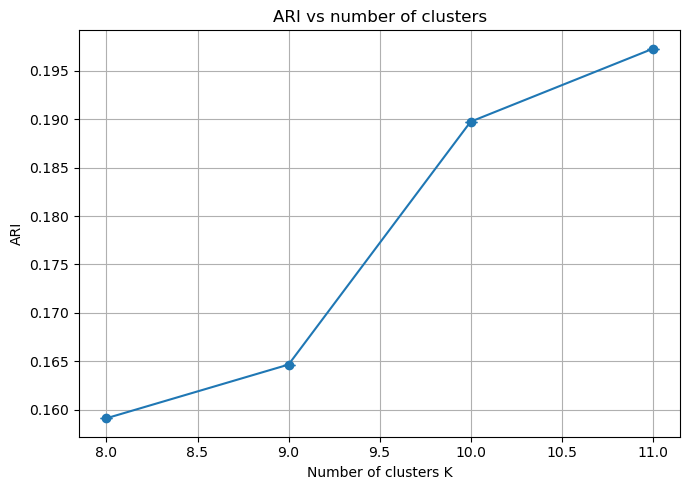

In [7]:
means = [results[k]["mean"] for k in Ks]
stds  = [results[k]["std"]  for k in Ks]

plt.figure(figsize=(7,5))
plt.errorbar(Ks, means, yerr=stds, marker="o", capsize=4)

plt.xlabel("Number of clusters K")
plt.ylabel("ARI")
plt.title("ARI vs number of clusters")
plt.grid(True)
plt.tight_layout()
plt.show()
